# The Penny Beat — do firms that beat by a *cent* pay for it later? 🪙
### Why clearing the analyst forecast by exactly one penny looks *managed*

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Discontinuity_real%3F: Confirmed](https://img.shields.io/badge/Discontinuity_real%3F-Confirmed-8b949e?style=flat-square)

Every quarter, Wall Street analysts publish a *consensus* forecast for a company's earnings per share. Beat it and the stock usually pops; miss it and it drops. So there's a huge temptation to *just barely* clear the bar — to turn a would-be miss of a penny into a **beat by a penny**, with a little accounting nudge.

If lots of firms do that, it leaves a fingerprint. Line up every company's *surprise* (actual EPS minus the forecast) and you'd expect a smooth bell curve. Instead there's a suspicious **spike right at +1¢** and a **dip just below zero** — mass shoved across the line. That's the **penny-beat discontinuity**. The follow-on claim: these penny-beaters, having borrowed from the future, *underperform* later.

> 📓 **This is the plain-language layer.** Want the *z*-scores, the placebo tests and the honest decomposition? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice, and this is a *synthetic* study.** The real data (analyst consensus vs actual EPS) is a licensed dataset a free retail stack can't reach — so we build a deterministic toy world with the effect dialled in, and test whether our engine *catches* it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from penny_beat import data, strategy as st

# Synthetic-only study: the reproducible core IS the deterministic synthetic world.
PANEL, TRUTH = data.synthetic_panel()   # seed 574, spike=0.55, penny_penalty=-0.05
HAVE_REAL = False                       # no free consensus-vs-actual EPS tape exists
print("synthetic penny-beat panel:", len(PANEL), "firm-quarters | HAVE_REAL:", HAVE_REAL)
print("panel fingerprint:", data.fingerprint(PANEL))


synthetic penny-beat panel: 6000 firm-quarters | HAVE_REAL: False
panel fingerprint: 1ad98df82652


## The answer first 🎯

| Question | Answer |
|---|---|
| Is the +1¢ spike real? | **Yes.** There's a huge excess of firms landing on exactly +1¢ — **988** where a smooth curve expects ~382, and the just-below-zero bins are half-empty. It's a smoking gun. |
| Do penny-beaters earn less later? | **Directionally yes** — they trail decisive beaters by **-4.92%**. |
| Is that a management penalty? | **Only about half of it.** Even with *zero* manipulation dialled in, penny-beaters still trail by **-1.83%** — because a 1¢ beat is a *smaller* beat, and small beats just drift less. The rest is real post-earnings drift, not punishment. |
| Could you trade it? | **No.** The data is licensed and unreachable, the penny bucket is tiny each quarter, and half the 'edge' is ordinary drift you could harvest directly. |

> The spike is famous and robust. The *return penalty* is real in the textbooks too (Bhojraj et al. 2009) — but half of the naive version is just arithmetic, and we can't test it on a real tape for free. So: interesting, `Weak`, not tradable.

## 1 · The claim

> *"Firms that beat consensus EPS by exactly a penny managed the number — and pay for it with weaker future returns."* (Burgstahler & Dichev 1997; Degeorge-Patel-Zeckhauser 1999; Bhojraj et al. 2009.)

Two ideas stacked. **First**, the *discontinuity*: if you histogram earnings surprises across thousands of firm-quarters, a smooth distribution would glide through zero. The real one doesn't — it has a cliff just below zero and a spike just above, because firms manage small misses into small beats. **Second**, the *penalty*: a number that was propped up this quarter has to give it back, so the just-beaters underperform the firms that beat *decisively* and honestly.

## 2 · So what?

The discontinuity is one of accounting's cleanest pieces of evidence that earnings are *managed* — it shows up without you having to prove any single firm cheated. And if the return penalty were real *and* separable, it would be a short: fade the penny-beaters, own the decisive ones. The desk has already looked at two other manipulation tells — the [Beneish M-score (229)](../../229-beneish-m-score/) (an accounting-ratio screen) and [Benford's Law (328)](../../328-benford-law/) (a leading-digit screen). This one is the *shape of the surprise histogram*.

## 3 · How would we even know?

1. **Build the surprise histogram.** For every firm-quarter, surprise = actual − forecast, rounded to the nearest cent. Count how many land in each bin.
2. **Look for the step.** Is the +1¢ bin far taller than its neighbours? Are the small-miss bins suspiciously empty? That's the management fingerprint.
3. **Compare returns.** Do the penny-beaters (+1¢) earn less over the next quarter than the decisive beaters (+3¢ or more)?
4. **Be honest about *why*.** A 1¢ beat is a *smaller* surprise than a 5¢ beat — and small surprises drift less anyway. So we check: how much of the gap survives if we turn *off* the manipulation entirely?

Catch: we can't get the real forecast-vs-actual data for free (it's licensed), so we build a *synthetic* world where we control the truth, and test whether the engine reads it correctly.

## 4 · The teardown — let's actually look

**The surprise histogram — is there a spike at +1¢?**

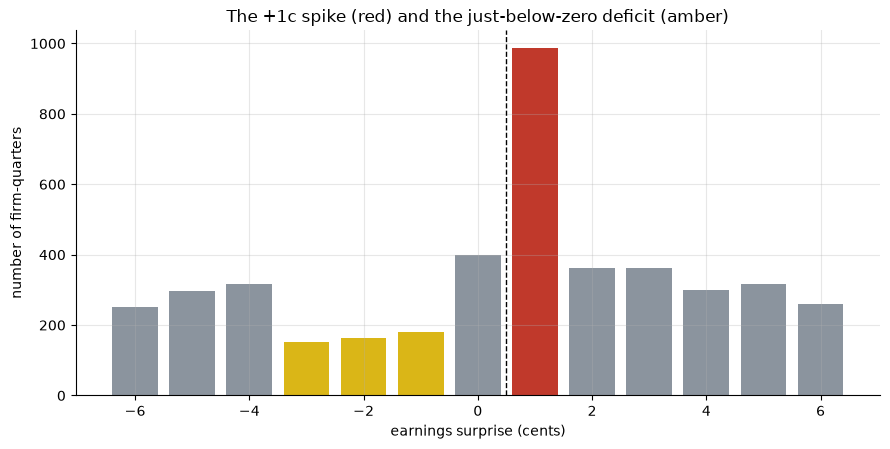

+1c bin: 988  vs smooth expectation ~382  -> excess +606 (z +17.7)


In [2]:
h = data.surprise_histogram(PANEL)
sl = h.loc[-6:6]
cols = [RED if k == 1 else (AMBER if k in (-1,-2,-3) else GREY) for k in sl.index]
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.bar(sl.index, sl.values, color=cols, width=.8)
ax.axvline(0.5, c='k', ls='--', lw=1)
ax.set_xlabel('earnings surprise (cents)'); ax.set_ylabel('number of firm-quarters')
ax.set_title('The +1c spike (red) and the just-below-zero deficit (amber)')
plt.tight_layout(); plt.show()
dz = st.discontinuity_z(PANEL)
print(f"+1c bin: {dz['c_penny']:.0f}  vs smooth expectation ~{dz['neighbour_avg']:.0f}  "
      f"-> excess {dz['excess']:+.0f} (z {dz['z']:+.1f})")

There it is. The +1¢ bin holds **988** firm-quarters where a smooth curve would put ~382 — an excess of **606** (a z-score of **+17.7**). And the small-miss bins to the left are depleted: mass was pushed *up* across zero. This is the earnings-management fingerprint, and it's unmistakable.

**Do the penny-beaters earn less later — and is it really a *penalty*?**

Compare penny-beaters (+1¢) to decisive beaters (≥+3¢), then re-run with the manipulation *turned off* to see how much of the gap is just ordinary drift.

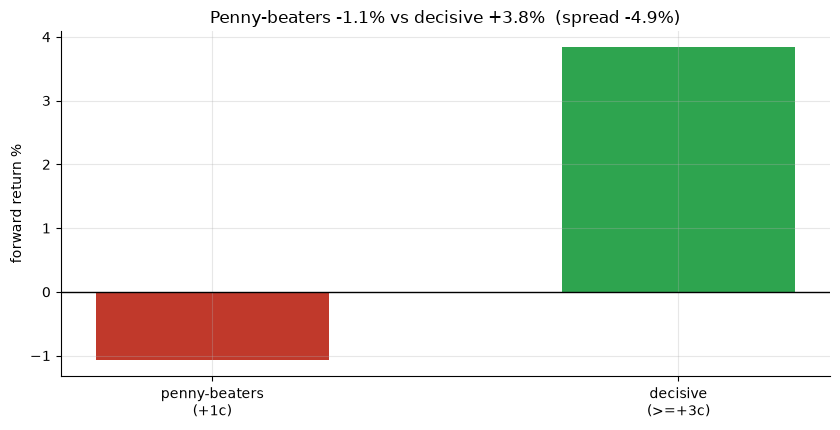

full spread   : -4.9%  (management + drift)
NO-manipulation spread: -1.8%  (pure drift -- a 1c beat is a smaller beat)


In [3]:
b = st.penny_vs_decisive(PANEL)
# composition-only world: same spike, but NO management penalty
pc, _ = data.synthetic_panel(penny_penalty=0.0)
bc = st.penny_vs_decisive(pc)
fig, ax = plt.subplots(figsize=(8.5, 4.4))
labs = ['penny-beaters\n(+1c)', 'decisive\n(>=+3c)']
ax.bar(labs, [b['penny_mean']*100, b['decisive_mean']*100], color=[RED, GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f"Penny-beaters {b['penny_mean']*100:+.1f}% vs decisive {b['decisive_mean']*100:+.1f}%  "
             f"(spread {b['spread']*100:+.1f}%)")
plt.tight_layout(); plt.show()
print(f"full spread   : {b['spread']*100:+.1f}%  (management + drift)")
print(f"NO-manipulation spread: {bc['spread']*100:+.1f}%  (pure drift -- a 1c beat is a smaller beat)")

Directionally the claim holds: penny-beaters trail decisive beaters by **-4.92%**. **But** flip the manipulation *off* and the gap is *still* **-1.83%** — because a 1¢ beat is a smaller surprise than a 5¢ beat, and small beats drift less regardless. So roughly **half** the 'penalty' is ordinary post-earnings drift, not punishment for cheating. That distinction is why this reads `Weak`, not a slam-dunk.

## 5 · The verdict

- **Signal — Weak.** The discontinuity is real and the penalty is directionally there, but half of it is mechanical drift, and there's no free real tape to confirm it on.
- **Tradability — Mirage.** Unreachable data, a tiny penny bucket each quarter, and half the edge is drift you could harvest more cheaply and directly.
- **Discontinuity real? — Confirmed.** The +1¢ spike / just-below-zero deficit is famous, robust, and the engine nails it (z +17.7).

## 6 · Could you actually trade it?

Not really. The trade would be *short the penny-beaters, long the decisive ones* — but you'd need licensed forecast-vs-actual data to even find them, the penny bucket is small and crowded, and once you strip out the ordinary drift there's not much *management* signal left to short. The **discontinuity** is a beautiful diagnostic of aggregate behaviour; it is not, by itself, a clean per-stock return edge.

## 7 · Going further 🚪

- **The other manipulation tells.** [Beneish M-score (229)](../../229-beneish-m-score/) and [Benford's Law (328)](../../328-benford-law/) attack the same question from the accounting ratios and the digits.
- **The real test needs the real tape.** With licensed I/B/E/S consensus-vs-actual data, you could histogram real surprises and run the within-threshold (managed vs honest) return test that separates management from drift.

*Think the penny-beat penalty is a clean short? Fork this, get point-in-time consensus data, and show a penny-minus-decisive spread that survives *after* you net out post-earnings drift.*